# Pelatihan Model Naïve Bayes — Deteksi Pesan Berbahaya

**Skripsi:** Perancangan Sistem Pengamanan Data dengan Klasifikasi Naïve Bayes dan Hybrid Cryptography AES–RSA  
**Dataset:** Dataset Gabungan (dataset_fixed + dataset_pesan + dataset_sms_spam + Dataset-Research)  
**Split:** Train 70% | Validasi 15% | Test 15%  
**Balancing:** SMOTE (Oversampling) pada data latih

In [5]:
!playwright install chromium

|                                                                                |   0% of 181.9 MiB
|■■■■■■■■                                                                        |  10% of 181.9 MiB
|■■■■■■■■■■■■■■■■                                                                |  20% of 181.9 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■                                                        |  30% of 181.9 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■                                                |  40% of 181.9 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■                                        |  50% of 181.9 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■                                |  60% of 181.9 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■                        |  70% of 181.9 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■                |  80% of 181.9 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■        |  90% of 

## 1. Import Library

In [6]:
import pandas as pd
import numpy as np
import joblib
import re
import os
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

print(" Semua library berhasil diimport (termasuk imbalanced-learn)")

 Semua library berhasil diimport (termasuk imbalanced-learn)


## 2. Load dan Gabungkan Dataset

Dua sumber data:
- **Dataset Dummy** (Peneliti): 1.235 data, Bahasa Indonesia
- **SMS Spam Collection** (Kaggle): 5.572 data, Bahasa Inggris → label `spam`→`Berisiko`, `ham`→`Tidak Berisiko`

In [7]:
print("=" * 60)
print("  LANGKAH 1 — LOAD DAN GABUNGKAN DATASET")
print("=" * 60)

# ── 1. dataset_fixed.csv ─────────────────────────────────────────
df_fixed = pd.read_csv('Dataset/dataset_fixed.csv')
df_fixed = df_fixed[['pesan','kategori','label']].copy()
print(f"\n[1] dataset_fixed.csv")
print(f"  Jumlah : {len(df_fixed)} baris")
print(f"  Label  : {df_fixed['label'].value_counts().to_dict()}")

# ── 2. dataset_pesan.csv ─────────────────────────────────────────
df_pesan = pd.read_csv('Dataset/dataset_pesan.csv')
df_pesan = df_pesan[['pesan','kategori','label']].copy()
print(f"\n[2] dataset_pesan.csv")
print(f"  Jumlah : {len(df_pesan)} baris")
print(f"  Label  : {df_pesan['label'].value_counts().to_dict()}")

# ── 3. dataset_sms_spam_v1.csv ───────────────────────────────────
# Label: 0=Normal/Ham, 1=Penipuan, 2=Promo/Spam
df_sms_raw = pd.read_csv('Dataset/dataset_sms_spam_v1.csv')
KATEGORI_SMS = {
    0: ('Percakapan Biasa',  'Tidak Berisiko'),
    1: ('Penipuan',          'Berisiko'),
    2: ('Penipuan',          'Berisiko'),
}
df_sms = pd.DataFrame({
    'pesan'    : df_sms_raw['Teks'],
    'kategori' : df_sms_raw['label'].map(lambda x: KATEGORI_SMS[x][0]),
    'label'    : df_sms_raw['label'].map(lambda x: KATEGORI_SMS[x][1]),
})
print(f"\n[3] dataset_sms_spam_v1.csv")
print(f"  Jumlah : {len(df_sms)} baris")
print(f"  Label asli → mapping : 0→Percakapan Biasa, 1&2→Penipuan")
print(f"  Label  : {df_sms['label'].value_counts().to_dict()}")

# ── 4. Dataset-Research.csv (TikTok Cyberbullying) ───────────────
# sentiment: -1=negatif/bullying, 1=positif/normal
df_res_raw = pd.read_csv('Dataset/Dataset-Research.csv')
df_res_raw['sentiment'] = df_res_raw['sentiment'].astype(str).str.strip()
KATEGORI_RES = {
    '-1': ('Kata Kasar & Ancaman', 'Berisiko'),
    '1' : ('Percakapan Biasa',     'Tidak Berisiko'),
}
df_res = pd.DataFrame({
    'pesan'    : df_res_raw['comment'],
    'kategori' : df_res_raw['sentiment'].map(
                    lambda x: KATEGORI_RES.get(str(x), ('Percakapan Biasa','Tidak Berisiko'))[0]),
    'label'    : df_res_raw['sentiment'].map(
                    lambda x: KATEGORI_RES.get(str(x), ('Percakapan Biasa','Tidak Berisiko'))[1]),
})
print(f"\n[4] Dataset-Research.csv")
print(f"  Jumlah : {len(df_res)} baris")
print(f"  Label asli → mapping : -1→Kata Kasar & Ancaman, 1→Percakapan Biasa")
print(f"  Label  : {df_res['label'].value_counts().to_dict()}")

# ── Gabungkan semua ───────────────────────────────────────────────
df_all = pd.concat([df_fixed, df_pesan, df_sms, df_res], ignore_index=True)
df_all['pesan'] = df_all['pesan'].astype(str).str.strip()
df_all = df_all.dropna(subset=['pesan'])
df_all = df_all[df_all['pesan'].str.len() >= 3]
df_all = df_all.drop_duplicates(subset=['pesan'])
df_all = df_all.reset_index(drop=True)

print(f"\n{'='*60}")
print(f"[Dataset Gabungan Final]")
print(f"  Total data : {len(df_all)} baris")
print(f"  Label      :")
for lbl, cnt in df_all['label'].value_counts().items():
    print(f"    - {lbl}: {cnt}")
print(f"  Kategori   :")
for kat, cnt in df_all['kategori'].value_counts().items():
    print(f"    - {kat}: {cnt}")
print(f"\nContoh data gabungan:")
print(df_all[['pesan','kategori','label']].sample(6, random_state=42).to_string(index=False))

df_all.to_csv('Dataset/dataset_pesan_gabungan.csv', index=False, encoding='utf-8-sig')
print(f"Dataset gabungan disimpan: {len(df_all)} baris")

  LANGKAH 1 — LOAD DAN GABUNGKAN DATASET

[1] dataset_fixed.csv
  Jumlah : 1235 baris
  Label  : {'Berisiko': 800, 'Tidak Berisiko': 435}

[2] dataset_pesan.csv
  Jumlah : 33270 baris
  Label  : {'Tidak Berisiko': 31989, 'Berisiko': 1281}

[3] dataset_sms_spam_v1.csv
  Jumlah : 1143 baris
  Label asli → mapping : 0→Percakapan Biasa, 1&2→Penipuan
  Label  : {'Berisiko': 574, 'Tidak Berisiko': 569}

[4] Dataset-Research.csv
  Jumlah : 1508 baris
  Label asli → mapping : -1→Kata Kasar & Ancaman, 1→Percakapan Biasa
  Label  : {'Tidak Berisiko': 832, 'Berisiko': 676}

[Dataset Gabungan Final]
  Total data : 37130 baris
  Label      :
    - Tidak Berisiko: 33812
    - Berisiko: 3318
  Kategori   :
    - Percakapan Biasa: 26402
    - Informasi Umum: 3193
    - Transaksi Aman: 2380
    - Kata Kasar & Ancaman: 2287
    - Jadwal & Kegiatan: 1837
    - Penipuan: 667
    - Phishing: 143
    - Social Engineering: 86
    - Malware: 69
    - Pencurian Akun: 66

Contoh data gabungan:
                 

## 3. Inisialisasi Tools NLP

In [8]:
print("=" * 60)
print("  INISIALISASI NLP")
print("=" * 60)

stemmer  = StemmerFactory().create_stemmer()
sw_base  = StopWordRemoverFactory().get_stop_words()
sw_extra = [
    'anda','kamu','saya','kami','kita','nya','ini','itu',
    'dengan','untuk','ada','akan','sudah','telah',
    'ya','yg','jg','gak','ga','deh','dong','nih','lah','sih',
    'ku','mu','klo','tapi','jadi','bisa','agar','juga',
    'the','a','an','is','are','was','were','be','been',
    'have','has','had','do','does','did','will','would',
    'can','could','may','might','shall','should','to','of',
    'in','on','at','by','for','with','from','as','that',
    'this','it','i','you','he','she','we','they','my',
    'your','his','her','our','their','not','no','but','or',
    'and','so','if','then','than','when','where','how',
    'what','who','which','just','get','got','u','ur','r',
]

# Kata kasar — TIDAK masuk stopwords agar jadi fitur model
KATA_KASAR = {
    'kontol','memek','pepek','titit','toket','ngentot','entot','ngewe',
    'colmek','coli','masturbasi','bokep','porno','telanjang','bugil',
    'binal','mesum','cabul','bejat',
    'anjing','bangsat','bajingan','brengsek','keparat','sialan',
    'babi','goblok','tolol','dungu','geblek','kampret',
    'asu','jancok','jancuk','cuk','kon','taik','tai','setan',
    'iblis','laknat','terkutuk','jahanam','lonte','sundal',
    'pelacur','jalang','murahan','perek',
    'kubunuh','mampusin','bacok','hajar','tonjok','siksa',
    'aniaya','habisi','musnahkan','gebuk','cekik',
    'kafir','rasis',
}

STOPWORDS = set(sw_base + sw_extra) - KATA_KASAR

POLA_URL = (
    r'(https?://|ftp://|bit\.ly|s\.id|rb\.gy|t\.ly|cutt\.ly'
    r'|tinyurl\.com|shorturl\.at|bit\.do|ow\.ly|is\.gd|tiny\.cc'
    r'|[\w-]+\.xyz|[\w-]+\.site)\S*'
)

print(f"  Stemmer      : Nazief-Adriani (Sastrawi) ")
print(f"  Stopwords    : {len(STOPWORDS)} kata (Sastrawi + custom + English)")
print(f"  Kata kasar   : {len(KATA_KASAR)} kata (blacklist, skip stopword & stemming)")
print(f"  Pola URL     : regex URL mencurigakan ")

  INISIALISASI NLP
  Stemmer      : Nazief-Adriani (Sastrawi) 
  Stopwords    : 207 kata (Sastrawi + custom + English)
  Kata kasar   : 62 kata (blacklist, skip stopword & stemming)
  Pola URL     : regex URL mencurigakan 


## 4. Preprocessing — Langkah 1: Case Folding

Mengubah seluruh teks menjadi huruf kecil (lowercase) untuk menyeragamkan bentuk kata.

In [9]:
print("=" * 60)
print("  LANGKAH 2 — CASE FOLDING")
print("=" * 60)
print("  Mengubah semua teks menjadi huruf kecil (lowercase)")

df_all['step_casefolding'] = df_all['pesan'].str.lower().str.strip()

# Tampilkan contoh (Tabel 3.10)
print("\n  Contoh (Tabel 3.10):")
print(f"  {'No':<4} {'Teks Asli':<55} {'Setelah Case Folding'}")
print("  " + "-"*110)
contoh_idx = df_all.sample(5, random_state=1).index
for no, i in enumerate(contoh_idx, 1):
    asli   = str(df_all['pesan'][i])[:52]
    bersih = str(df_all['step_casefolding'][i])[:52]
    print(f"  {no:<4} {asli:<55} {bersih}")

  LANGKAH 2 — CASE FOLDING
  Mengubah semua teks menjadi huruf kecil (lowercase)

  Contoh (Tabel 3.10):
  No   Teks Asli                                               Setelah Case Folding
  --------------------------------------------------------------------------------------------------------------
  1    akting                                                  akting
  2    SUMATERA MERDEKA !!                                     sumatera merdeka !!
  3    gila bener, solok selatan terkhusu wilayah muarolabu    gila bener, solok selatan terkhusu wilayah muarolabu
  4    d tmpat ku pak,mti nya mghrib nylanya stngah 9 pgi..    d tmpat ku pak,mti nya mghrib nylanya stngah 9 pgi..
  5    Kalo kita telat bayar listrik trss mintaa maaf kelar    kalo kita telat bayar listrik trss mintaa maaf kelar


## 5. Preprocessing — Langkah 2–3: Pattern Replacement + Tokenisasi

Menandai pola khusus (URL, nomor HP, OTP, nominal uang) lalu memecah teks menjadi token kata.

In [10]:
print("=" * 60)
print("  LANGKAH 3 — PATTERN REPLACEMENT + TOKENISASI")
print("=" * 60)

def tokenisasi(text):
    # Pattern replacement
    text = re.sub(POLA_URL,                      'URL_CURIGA',     text)
    text = re.sub(r'\b0\d[\d\-]{8,12}\b',     'NOMOR_HP_ASING', text)
    text = re.sub(r'\b\d{5,8}\b',               'KODE_OTP',       text)
    text = re.sub(
        r'rp[\s]?\d+[\.,]?\d*\s*(juta|ribu|rb)?',
        'NOMINAL_UANG', text
    )
    text = re.sub(r'\b\d+\b', '', text)
    text = re.sub(r'[^a-z_\s]', ' ', text)
    return [t for t in text.split() if len(t) > 0]

df_all['step_tokenisasi'] = df_all['step_casefolding'].apply(tokenisasi)

# Tampilkan contoh (Tabel 3.11)
print("\n  Contoh (Tabel 3.11):")
for no, i in enumerate(contoh_idx, 1):
    tokens = df_all['step_tokenisasi'][i]
    print(f"  {no}. {str(df_all['step_casefolding'][i])[:45]}")
    print(f"     → {tokens[:8]}{'...' if len(tokens)>8 else ''}")

  LANGKAH 3 — PATTERN REPLACEMENT + TOKENISASI

  Contoh (Tabel 3.11):
  1. akting
     → ['akting']
  2. sumatera merdeka !!
     → ['sumatera', 'merdeka']
  3. gila bener, solok selatan terkhusu wilayah mu
     → ['gila', 'bener', 'solok', 'selatan', 'terkhusu', 'wilayah', 'muarolabuh', 'mati']...
  4. d tmpat ku pak,mti nya mghrib nylanya stngah 
     → ['d', 'tmpat', 'ku', 'pak', 'mti', 'nya', 'mghrib', 'nylanya']...
  5. kalo kita telat bayar listrik trss mintaa maa
     → ['kalo', 'kita', 'telat', 'bayar', 'listrik', 'trss', 'mintaa', 'maaf']...


## 6. Preprocessing — Langkah 4: Stopword Removal

Membuang kata umum yang tidak bermakna. Kata kasar **tidak dihapus** agar tetap menjadi fitur model.

In [11]:
print("=" * 60)
print("  LANGKAH 4 — STOPWORD REMOVAL")
print("=" * 60)

def hapus_stopword(tokens):
    return [
        t for t in tokens
        if t.isupper()
        or t in KATA_KASAR
        or (t not in STOPWORDS and len(t) > 1)
    ]

df_all['step_stopword'] = df_all['step_tokenisasi'].apply(hapus_stopword)

# Tampilkan contoh (Tabel 3.12)
print("\n  Contoh (Tabel 3.12):")
for no, i in enumerate(contoh_idx, 1):
    before = df_all['step_tokenisasi'][i]
    after  = df_all['step_stopword'][i]
    print(f"  {no}. Sebelum: {before[:6]}...")
    print(f"     Sesudah: {after[:6]}...")

  LANGKAH 4 — STOPWORD REMOVAL

  Contoh (Tabel 3.12):
  1. Sebelum: ['akting']...
     Sesudah: ['akting']...
  2. Sebelum: ['sumatera', 'merdeka']...
     Sesudah: ['sumatera', 'merdeka']...
  3. Sebelum: ['gila', 'bener', 'solok', 'selatan', 'terkhusu', 'wilayah']...
     Sesudah: ['gila', 'bener', 'solok', 'selatan', 'terkhusu', 'wilayah']...
  4. Sebelum: ['d', 'tmpat', 'ku', 'pak', 'mti', 'nya']...
     Sesudah: ['tmpat', 'pak', 'mti', 'mghrib', 'nylanya', 'stngah']...
  5. Sebelum: ['kalo', 'kita', 'telat', 'bayar', 'listrik', 'trss']...
     Sesudah: ['kalo', 'telat', 'bayar', 'listrik', 'trss', 'mintaa']...


## 7. Preprocessing — Langkah 5: Stemming

Mengubah kata ke bentuk dasar menggunakan algoritma Nazief-Adriani (library Sastrawi). Token khusus dan kata kasar tidak di-stem.

In [12]:
print("=" * 60)
print("  LANGKAH 5 — STEMMING (Nazief-Adriani via Sastrawi)")
print("=" * 60)
print("  Token khusus (URL_CURIGA, KODE_OTP, dll) dan kata kasar SKIP stemming")
print("  Proses ini memerlukan waktu karena dataset besar, harap tunggu...\n")

def stemming(tokens):
    return [
        t if (t.isupper() or t in KATA_KASAR)
        else stemmer.stem(t)
        for t in tokens
    ]

start = time.time()
df_all['step_stemming'] = df_all['step_stopword'].apply(stemming)
df_all['teks_bersih']   = df_all['step_stemming'].apply(
    lambda t: ' '.join(t) if t else 'PESAN_KOSONG'
)
elapsed = time.time() - start
print(f"   Stemming selesai dalam {elapsed:.1f} detik")
print(f"  Total data setelah preprocessing: {len(df_all)}")

# Tampilkan ringkasan 5 tahap (Tabel 3.13)
print("\n  ── Ringkasan 5 Tahap Preprocessing ──")
for lbl in ['Berisiko', 'Tidak Berisiko']:
    idx = df_all[df_all['label'] == lbl].index[0]
    print(f"\n  [{lbl}]")
    print(f"  Asli       : {df_all['pesan'][idx]}")
    print(f"  CaseFold   : {df_all['step_casefolding'][idx]}")
    print(f"  Tokenisasi : {df_all['step_tokenisasi'][idx]}")
    print(f"  Stopword   : {df_all['step_stopword'][idx]}")
    print(f"  Stemming   : {df_all['step_stemming'][idx]}")
    print(f"  Teks Final : {df_all['teks_bersih'][idx]}")

  LANGKAH 5 — STEMMING (Nazief-Adriani via Sastrawi)
  Token khusus (URL_CURIGA, KODE_OTP, dll) dan kata kasar SKIP stemming
  Proses ini memerlukan waktu karena dataset besar, harap tunggu...

   Stemming selesai dalam 1693.8 detik
  Total data setelah preprocessing: 37130

  ── Ringkasan 5 Tahap Preprocessing ──

  [Berisiko]
  Asli       : dasar sialan
  CaseFold   : dasar sialan
  Tokenisasi : ['dasar', 'sialan']
  Stopword   : ['dasar', 'sialan']
  Stemming   : ['dasar', 'sialan']
  Teks Final : dasar sialan

  [Tidak Berisiko]
  Asli       : Transfer berhasil. Rp45.000 telah dikirim ke rekening BRI atas nama Rina.
  CaseFold   : transfer berhasil. rp45.000 telah dikirim ke rekening bri atas nama rina.
  Tokenisasi : ['transfer', 'berhasil', '_', 'telah', 'dikirim', 'ke', 'rekening', 'bri', 'atas', 'nama', 'rina']
  Stopword   : ['transfer', 'berhasil', 'dikirim', 'rekening', 'bri', 'atas', 'nama', 'rina']
  Stemming   : ['transfer', 'hasil', 'kirim', 'rekening', 'bri', 'atas', 'n

## 8. Deduplikasi Teks Bersih

Sebelum data dibagi, dilakukan penghapusan duplikat pada kolom `teks_bersih` (hasil preprocessing). Dua pesan yang berbeda secara teks asli bisa menjadi **identik** setelah melalui proses case folding, tokenisasi, stopword removal, dan stemming. Jika tidak dihapus, teks yang sama berpotensi masuk ke data latih sekaligus data uji sehingga menyebabkan **kebocoran data (data leakage)** yang membuat evaluasi model menjadi tidak valid.

In [13]:
print("=" * 60)
print("  LANGKAH 5.5 — DEDUPLIKASI TEKS BERSIH")
print("=" * 60)

sebelum = len(df_all)

# Hapus duplikat berdasarkan teks_bersih (hasil preprocessing)
# Teks asli berbeda bisa jadi identik setelah stemming & stopword removal
# Jika tidak dihapus → teks yang sama bisa masuk train DAN test (data leakage)
df_all = df_all.drop_duplicates(subset=['teks_bersih']).reset_index(drop=True)

sesudah   = len(df_all)
terhapus  = sebelum - sesudah

print(f"\n  Sebelum deduplikasi : {sebelum} baris")
print(f"  Setelah deduplikasi : {sesudah} baris")
print(f"  Teks duplikat dihapus: {terhapus} baris")
print(f"\n  Distribusi label setelah deduplikasi:")
for lbl, cnt in df_all['label'].value_counts().items():
    print(f"    - {lbl}: {cnt}")

# Verifikasi tidak ada duplikat tersisa
sisa_duplikat = df_all['teks_bersih'].duplicated().sum()
if sisa_duplikat == 0:
    print(f"\n  ✅ Tidak ada duplikat tersisa — data siap dibagi (split)")
else:
    print(f"\n  ⚠️  Masih ada {sisa_duplikat} duplikat!")

  LANGKAH 5.5 — DEDUPLIKASI TEKS BERSIH

  Sebelum deduplikasi : 37130 baris
  Setelah deduplikasi : 35159 baris
  Teks duplikat dihapus: 1971 baris

  Distribusi label setelah deduplikasi:
    - Tidak Berisiko: 32038
    - Berisiko: 3121

  ✅ Tidak ada duplikat tersisa — data siap dibagi (split)


## 9. Pembagian Data — Split 70:15:15

Data dibagi menjadi **tiga subset** dengan rasio 70:15:15 menggunakan stratified split sesuai Tabel 3.15.

In [14]:
print("=" * 60)
print("  LANGKAH 6 — PEMBAGIAN DATA (70 : 15 : 15)")
print("=" * 60)

label_map     = {'Berisiko': 1, 'Tidak Berisiko': 0}
label_map_inv = {1: 'Berisiko', 0: 'Tidak Berisiko'}

X = df_all['teks_bersih']
y = df_all['label'].map(label_map)

# Step 1: Pisahkan train 70% | sisa 30%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Step 2: Bagi sisa menjadi validasi 15% | test 15% (50:50 dari 30%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\n  Total data   : {len(df_all)}")
print(f"  Data Latih   : {len(X_train)} ({len(X_train)/len(df_all)*100:.1f}%) "
      f"| Berisiko={sum(y_train==1)} | Tidak Berisiko={sum(y_train==0)}")
print(f"  Data Validasi: {len(X_val)}  ({len(X_val)/len(df_all)*100:.1f}%) "
      f"| Berisiko={sum(y_val==1)}   | Tidak Berisiko={sum(y_val==0)}")
print(f"  Data Uji     : {len(X_test)}  ({len(X_test)/len(df_all)*100:.1f}%) "
      f"| Berisiko={sum(y_test==1)}   | Tidak Berisiko={sum(y_test==0)}")

# Tampilkan distribusi (Tabel 3.15)
print("\n  Tabel 3.15 — Distribusi Pembagian Data:")
print(f"  {'Subset':<20} {'Berisiko':>12} {'Tidak Berisiko':>16} {'Total':>8}")
print("  " + "-"*58)
for nama, yl in [("Data Latih (70%)", y_train),
                  ("Data Validasi (15%)", y_val),
                  ("Data Uji (15%)", y_test)]:
    print(f"  {nama:<20} {sum(yl==1):>12} {sum(yl==0):>16} {len(yl):>8}")
print(f"  {'Total':<20} {sum(y==1):>12} {sum(y==0):>16} {len(y):>8}")

  LANGKAH 6 — PEMBAGIAN DATA (70 : 15 : 15)

  Total data   : 35159
  Data Latih   : 24611 (70.0%) | Berisiko=2185 | Tidak Berisiko=22426
  Data Validasi: 5274  (15.0%) | Berisiko=468   | Tidak Berisiko=4806
  Data Uji     : 5274  (15.0%) | Berisiko=468   | Tidak Berisiko=4806

  Tabel 3.15 — Distribusi Pembagian Data:
  Subset                   Berisiko   Tidak Berisiko    Total
  ----------------------------------------------------------
  Data Latih (70%)             2185            22426    24611
  Data Validasi (15%)           468             4806     5274
  Data Uji (15%)                468             4806     5274
  Total                        3121            32038    35159


## 9.5. Penanganan Ketidakseimbangan Data — SMOTE & Undersampling

Dataset gabungan memiliki distribusi label yang tidak seimbang (~91% Tidak Berisiko vs ~9% Berisiko). Jika dibiarkan, model Naive Bayes akan bias memprediksi semua pesan sebagai 'Tidak Berisiko'.

Strategi yang digunakan:
- **SMOTE** (Synthetic Minority Oversampling Technique): Membuat data sintetis untuk kelas minoritas (Berisiko)
- **RandomUnderSampler**: Mengurangi kelas mayoritas (Tidak Berisiko) agar rasio seimbang
- Balancing **hanya dilakukan pada data latih** — data validasi dan test tetap original (tidak di-balance)
  agar evaluasi mencerminkan kondisi nyata di lapangan.

In [17]:
print("=" * 60)
print("  LANGKAH 6.5 — SMOTE + UNDERSAMPLING (DATA LATIH SAJA)")
print("=" * 60)

print(f"\n  Distribusi SEBELUM balancing (data latih):")
print(f"    Berisiko      : {sum(y_train==1):,}")
print(f"    Tidak Berisiko: {sum(y_train==0):,}")
print(f"    Rasio         : 1 : {sum(y_train==0)//max(sum(y_train==1),1):.0f}")

# ── Strategi: SMOTE dulu, lalu Undersampling ─────────────────────
# Target: Berisiko naik ke 40% dari data latih via SMOTE,
#         lalu Tidak Berisiko dikurangi ke 60% via Undersampling
# Hasil akhir rasio 40:60 (lebih realistis, tidak terlalu artificial)

total_train  = len(y_train)
target_minor = int(total_train * 0.40)   # 40% = kelas Berisiko
target_major = int(total_train * 0.60)   # 60% = kelas Tidak Berisiko

# Pastikan target SMOTE tidak lebih besar dari jumlah mayoritas
target_minor = min(target_minor, sum(y_train==0))

# Step 1: SMOTE — perbanyak kelas minoritas (Berisiko)
smote = SMOTE(
    sampling_strategy={1: target_minor},
    random_state=42,
    k_neighbors=min(5, sum(y_train==1)-1)
)
X_train_sm, y_train_sm = smote.fit_resample(X_train_tfidf, y_train)

# Step 2: Undersampling — kurangi kelas mayoritas (Tidak Berisiko)
rus = RandomUnderSampler(
    sampling_strategy={0: target_major},
    random_state=42
)
X_train_bal, y_train_bal = rus.fit_resample(X_train_sm, y_train_sm)

print(f"\n  Distribusi SESUDAH balancing (data latih):")
print(f"    Berisiko      : {sum(y_train_bal==1):,}")
print(f"    Tidak Berisiko: {sum(y_train_bal==0):,}")
total_bal = len(y_train_bal)
print(f"    Rasio         : {sum(y_train_bal==1)/total_bal*100:.1f}% : {sum(y_train_bal==0)/total_bal*100:.1f}%")

print(f"\n  ⚠️  Catatan:")
print(f"    - Data validasi & test TIDAK di-balance (tetap original)")
print(f"    - Ini agar evaluasi mencerminkan kondisi nyata")
print(f"    - Model akan dilatih dengan X_train_bal & y_train_bal")


  LANGKAH 6.5 — SMOTE + UNDERSAMPLING (DATA LATIH SAJA)

  Distribusi SEBELUM balancing (data latih):
    Berisiko      : 2,185
    Tidak Berisiko: 22,426
    Rasio         : 1 : 10

  Distribusi SESUDAH balancing (data latih):
    Berisiko      : 9,844
    Tidak Berisiko: 14,766
    Rasio         : 40.0% : 60.0%

  ⚠️  Catatan:
    - Data validasi & test TIDAK di-balance (tetap original)
    - Ini agar evaluasi mencerminkan kondisi nyata
    - Model akan dilatih dengan X_train_bal & y_train_bal


## 10. Ekstraksi Fitur — TF-IDF

Mengubah teks menjadi representasi numerik menggunakan TF-IDF Vectorizer sesuai Tabel 3.14.

In [16]:
print("=" * 60)
print("  LANGKAH 7 — EKSTRAKSI FITUR TF-IDF")
print("=" * 60)

# Konfigurasi sesuai Tabel 3.14 rancangan skripsi
tfidf = TfidfVectorizer(
    ngram_range  = (1, 2),    # unigram + bigram
    max_features = 10000,     # 10.000 fitur terpenting
    sublinear_tf = True,      # transformasi log TF
    min_df       = 2,         # abaikan kata muncul < 2 dokumen
    analyzer     = 'word',    # analisis level kata
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

feature_names = tfidf.get_feature_names_out()
mean_tfidf    = X_train_tfidf.mean(axis=0).A1
top15_idx     = mean_tfidf.argsort()[::-1][:15]

print(f"\n  Parameter TF-IDF (Tabel 3.14):")
print(f"    ngram_range  : (1, 2)")
print(f"    max_features : 10.000")
print(f"    sublinear_tf : True")
print(f"    min_df       : 2")
print(f"    analyzer     : word")
print(f"\n  Dimensi matriks training  : {X_train_tfidf.shape}")
print(f"  Dimensi matriks validasi  : {X_val_tfidf.shape}")
print(f"  Dimensi matriks testing   : {X_test_tfidf.shape}")
print(f"  Jumlah fitur (vocabulary) : {len(tfidf.vocabulary_)}")
print(f"\n  Top 15 fitur TF-IDF tertinggi:")
for i, idx in enumerate(top15_idx, 1):
    print(f"    {i:2d}. {feature_names[idx]:<30} bobot: {mean_tfidf[idx]:.5f}")

  LANGKAH 7 — EKSTRAKSI FITUR TF-IDF

  Parameter TF-IDF (Tabel 3.14):
    ngram_range  : (1, 2)
    max_features : 10.000
    sublinear_tf : True
    min_df       : 2
    analyzer     : word

  Dimensi matriks training  : (24611, 10000)
  Dimensi matriks validasi  : (5274, 10000)
  Dimensi matriks testing   : (5274, 10000)
  Jumlah fitur (vocabulary) : 10000

  Top 15 fitur TF-IDF tertinggi:
     1. mati                           bobot: 0.02250
     2. pak                            bobot: 0.02160
     3. maaf                           bobot: 0.01936
     4. lampu                          bobot: 0.01727
     5. jam                            bobot: 0.01642
     6. hidup                          bobot: 0.01396
     7. mati lampu                     bobot: 0.01354
     8. aja                            bobot: 0.01302
     9. listrik                        bobot: 0.01284
    10. minta                          bobot: 0.01229
    11. pln                            bobot: 0.01103
    12. ak

## 11. Pelatihan Model — Multinomial Naïve Bayes

Model dilatih menggunakan Multinomial Naïve Bayes dengan Laplace smoothing α=1 sesuai rancangan skripsi.

In [18]:
print("=" * 60)
print("  LANGKAH 8 — TRAINING MODEL MULTINOMIAL NAÏVE BAYES")
print("=" * 60)
print("  Laplace smoothing alpha = 1")
print("  Data latih: X_train_bal (setelah SMOTE + Undersampling)")

nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_bal, y_train_bal)   # ← pakai data yang sudah di-balance

# Prior probability
classes = nb_model.classes_
priors  = np.exp(nb_model.class_log_prior_)
print(f"\n  Model selesai dilatih")
print(f"\n  Prior Probability P(H) (dari data balanced):")
for c, p in zip(classes, priors):
    print(f"    P({label_map_inv[c]}) = {p:.4f}")
print(f"\n  Vocabulary size   : {len(nb_model.feature_log_prob_[0])}")
print(f"  Jumlah kelas      : {len(nb_model.classes_)}")

  LANGKAH 8 — TRAINING MODEL MULTINOMIAL NAÏVE BAYES
  Laplace smoothing alpha = 1
  Data latih: X_train_bal (setelah SMOTE + Undersampling)

  Model selesai dilatih

  Prior Probability P(H) (dari data balanced):
    P(Tidak Berisiko) = 0.6000
    P(Berisiko) = 0.4000

  Vocabulary size   : 10000
  Jumlah kelas      : 2


## 12. Evaluasi Model — Data Validasi

Evaluasi performa model pada data validasi (15%) untuk monitoring overfitting.

In [19]:
print("=" * 60)
print("  LANGKAH 9A — EVALUASI PADA DATA VALIDASI (15%)")
print("=" * 60)

y_val_pred = nb_model.predict(X_val_tfidf)

acc_v  = accuracy_score(y_val, y_val_pred)
prec_v = precision_score(y_val, y_val_pred, zero_division=0)
rec_v  = recall_score(y_val, y_val_pred, zero_division=0)
f1_v   = f1_score(y_val, y_val_pred, zero_division=0)
cm_v   = confusion_matrix(y_val, y_val_pred)

print(f"\n  [Data Validasi — {len(y_val)} sampel]")
print(f"  Accuracy  : {acc_v:.4f}  ({acc_v*100:.2f}%)")
print(f"  Precision : {prec_v:.4f}  ({prec_v*100:.2f}%)")
print(f"  Recall    : {rec_v:.4f}  ({rec_v*100:.2f}%)")
print(f"  F1-Score  : {f1_v:.4f}  ({f1_v*100:.2f}%)")
print(f"\n  Confusion Matrix (Validasi):")
print(f"  {'':<26}  Pred: Berisiko  Pred: Tidak Berisiko")
print(f"  {'Aktual: Berisiko':<26}  TP={cm_v[1][1]:8d}      FN={cm_v[1][0]:8d}")
print(f"  {'Aktual: Tidak Berisiko':<26}  FP={cm_v[0][1]:8d}      TN={cm_v[0][0]:8d}")
print(f"\n{classification_report(y_val, y_val_pred, target_names=['Tidak Berisiko','Berisiko'])}")

  LANGKAH 9A — EVALUASI PADA DATA VALIDASI (15%)

  [Data Validasi — 5274 sampel]
  Accuracy  : 0.9295  (92.95%)
  Precision : 0.5913  (59.13%)
  Recall    : 0.6645  (66.45%)
  F1-Score  : 0.6258  (62.58%)

  Confusion Matrix (Validasi):
                              Pred: Berisiko  Pred: Tidak Berisiko
  Aktual: Berisiko            TP=     311      FN=     157
  Aktual: Tidak Berisiko      FP=     215      TN=    4591

                precision    recall  f1-score   support

Tidak Berisiko       0.97      0.96      0.96      4806
      Berisiko       0.59      0.66      0.63       468

      accuracy                           0.93      5274
     macro avg       0.78      0.81      0.79      5274
  weighted avg       0.93      0.93      0.93      5274



## 13. Evaluasi Model — Data Uji (Final)

Evaluasi akhir performa model pada data uji (15%) yang belum pernah dilihat model selama training maupun validasi.

In [20]:
print("=" * 60)
print("  LANGKAH 9B — EVALUASI PADA DATA UJI / TEST (15%)")
print("=" * 60)

y_test_pred = nb_model.predict(X_test_tfidf)

acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec  = recall_score(y_test, y_test_pred, zero_division=0)
f1   = f1_score(y_test, y_test_pred, zero_division=0)
cm   = confusion_matrix(y_test, y_test_pred)
TP   = cm[1][1]; FN = cm[1][0]; FP = cm[0][1]; TN = cm[0][0]

print(f"\n  [Data Uji — {len(y_test)} sampel]")
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}  ({prec*100:.2f}%)")
print(f"  Recall    : {rec:.4f}  ({rec*100:.2f}%)")
print(f"  F1-Score  : {f1:.4f}  ({f1*100:.2f}%)")
print(f"\n  Confusion Matrix (Data Uji):")
print(f"  {'':<26}  Pred: Berisiko  Pred: Tidak Berisiko")
print(f"  {'Aktual: Berisiko':<26}  TP={TP:8d}      FN={FN:8d}")
print(f"  {'Aktual: Tidak Berisiko':<26}  FP={FP:8d}      TN={TN:8d}")
print(f"\n{classification_report(y_test, y_test_pred, target_names=['Tidak Berisiko','Berisiko'])}")

# Ringkasan perbandingan validasi vs test
print("\n  ── Perbandingan Validasi vs Test ──")
print(f"  {'Metrik':<15} {'Validasi':>12} {'Test':>12}")
print("  " + "-"*40)
for nama, v, t in [
    ("Accuracy",  acc_v,  acc),
    ("Precision", prec_v, prec),
    ("Recall",    rec_v,  rec),
    ("F1-Score",  f1_v,   f1),
]:
    print(f"  {nama:<15} {v*100:>10.2f}%  {t*100:>10.2f}%")

  LANGKAH 9B — EVALUASI PADA DATA UJI / TEST (15%)

  [Data Uji — 5274 sampel]
  Accuracy  : 0.9300  (93.00%)
  Precision : 0.5936  (59.36%)
  Recall    : 0.6709  (67.09%)
  F1-Score  : 0.6299  (62.99%)

  Confusion Matrix (Data Uji):
                              Pred: Berisiko  Pred: Tidak Berisiko
  Aktual: Berisiko            TP=     314      FN=     154
  Aktual: Tidak Berisiko      FP=     215      TN=    4591

                precision    recall  f1-score   support

Tidak Berisiko       0.97      0.96      0.96      4806
      Berisiko       0.59      0.67      0.63       468

      accuracy                           0.93      5274
     macro avg       0.78      0.81      0.80      5274
  weighted avg       0.93      0.93      0.93      5274


  ── Perbandingan Validasi vs Test ──
  Metrik              Validasi         Test
  ----------------------------------------
  Accuracy             92.95%       93.00%
  Precision            59.13%       59.36%
  Recall               66.45

## 14. Visualisasi Confusion Matrix

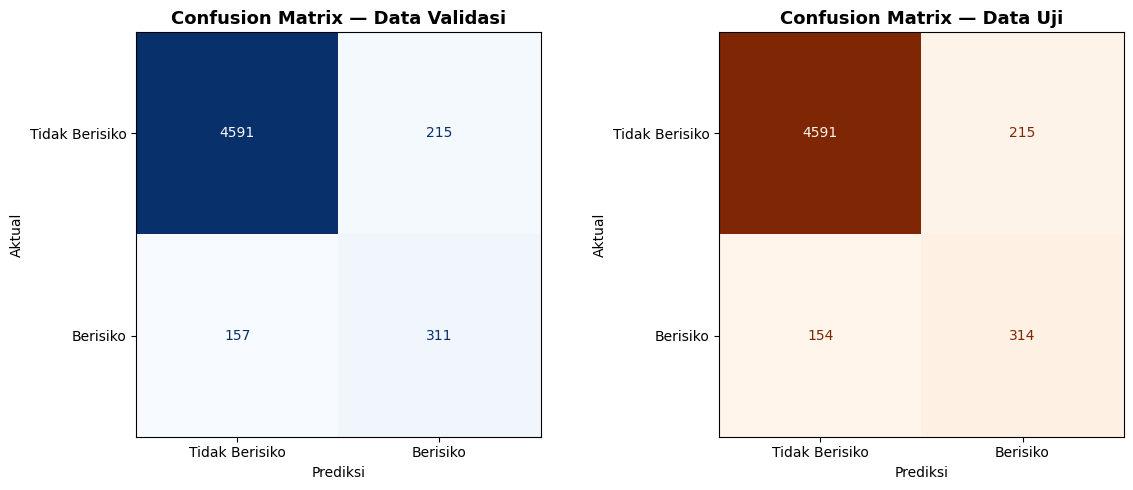

Confusion matrix disimpan ke output/confusion_matrix.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels_display = ['Tidak Berisiko', 'Berisiko']

# Confusion Matrix Validasi
disp_v = ConfusionMatrixDisplay(confusion_matrix=cm_v,
                                 display_labels=labels_display)
disp_v.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Data Validasi', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# Confusion Matrix Test
disp_t = ConfusionMatrixDisplay(confusion_matrix=cm,
                                 display_labels=labels_display)
disp_t.plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('Confusion Matrix — Data Uji', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')

plt.tight_layout()
os.makedirs('output', exist_ok=True)
plt.savefig('output/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix disimpan ke output/confusion_matrix.png")

## 15. Visualisasi Perbandingan Metrik Evaluasi

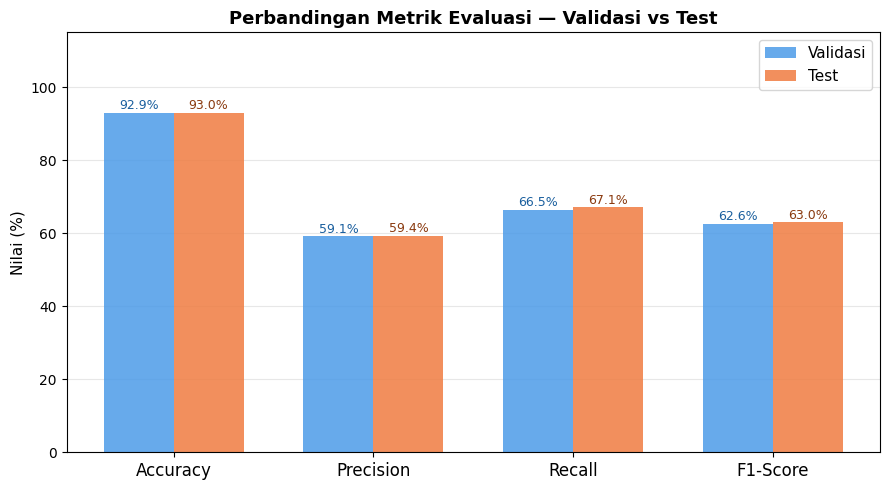

 Grafik metrik disimpan ke output/metrik_evaluasi.png


In [22]:
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
val_scores = [acc_v*100, prec_v*100, rec_v*100, f1_v*100]
test_scores = [acc*100,  prec*100,  rec*100,   f1*100]

x   = np.arange(len(metrics))
w   = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, val_scores,  w, label='Validasi', color='#4C9BE8', alpha=0.85)
bars2 = ax.bar(x + w/2, test_scores, w, label='Test',     color='#F07C41', alpha=0.85)

ax.set_ylim(0, 115)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Nilai (%)', fontsize=11)
ax.set_title('Perbandingan Metrik Evaluasi — Validasi vs Test', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9, color='#1a5f9e')
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9, color='#8a3a0f')

plt.tight_layout()
plt.savefig('output/metrik_evaluasi.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Grafik metrik disimpan ke output/metrik_evaluasi.png")

## 16. Simpan Model ke Joblib

Model disimpan **tanpa fungsi/lambda** agar aman di-load di environment manapun.

In [23]:
print("=" * 60)
print("  LANGKAH 10 — SIMPAN MODEL KE JOBLIB")
print("=" * 60)

os.makedirs('model', exist_ok=True)
output_path = 'model/model_naive_bayes.joblib'

joblib.dump({
    'model'      : nb_model,
    'vectorizer' : tfidf,
    'stopwords'  : list(STOPWORDS),
    'kata_kasar' : list(KATA_KASAR),
    'pola_url'   : POLA_URL,
    'label_map'  : label_map,
    'metadata'   : {
        'total_data'       : len(df_all),
        'train_size'       : len(X_train),
        'val_size'         : len(X_val),
        'test_size'        : len(X_test),
        'accuracy_val'     : round(acc_v,  4),
        'precision_val'    : round(prec_v, 4),
        'recall_val'       : round(rec_v,  4),
        'f1_score_val'     : round(f1_v,   4),
        'accuracy_test'    : round(acc,    4),
        'precision_test'   : round(prec,   4),
        'recall_test'      : round(rec,    4),
        'f1_score_test'    : round(f1,     4),
        'confusion_matrix_val'  : cm_v.tolist(),
        'confusion_matrix_test' : cm.tolist(),
        'label_encoding'   : '1=Berisiko, 0=Tidak Berisiko',
        'tfidf_params'     : {
            'ngram_range'   : '(1,2)',
            'max_features'  : 10000,
            'sublinear_tf'  : True,
            'min_df'        : 2,
            'analyzer'      : 'word',
        },
        'nb_alpha'         : 1.0,
        'split_ratio'      : '70:15:15',
        'dataset_sources'  : ['dataset_fixed.csv (dummy)', 'spam.csv (Kaggle)'],
        'preprocessing_steps' : [
            '1. Case Folding (lowercase)',
            '2. Pattern Replacement (URL_CURIGA/NOMOR_HP_ASING/KODE_OTP/NOMINAL_UANG)',
            '3. Tokenisasi',
            '4. Stopword Removal (Sastrawi + custom English, kata kasar dijaga)',
            '5. Stemming Nazief-Adriani (token khusus & kata kasar skip)',
            '6. Ekstraksi Fitur TF-IDF (1,2)-gram max 10000 fitur',
        ],
    }
}, output_path)

size_kb = os.path.getsize(output_path) / 1024
print(f"    Model disimpan ke: {output_path}")
print(f"  Ukuran file : {size_kb:.1f} KB")
print(f"  Keys        : {list(joblib.load(output_path).keys())}")

  LANGKAH 10 — SIMPAN MODEL KE JOBLIB
    Model disimpan ke: model/model_naive_bayes.joblib
  Ukuran file : 2101.5 KB
  Keys        : ['model', 'vectorizer', 'stopwords', 'kata_kasar', 'pola_url', 'label_map', 'metadata']


## 17. Uji Prediksi — Fungsi Klasifikasi Berlapis

Implementasi fungsi `prediksi()` dengan 6 layer rule-based sesuai Gambar 3.3 rancangan skripsi.

In [26]:
# ── Fungsi prediksi berlapis sesuai Gambar 3.3 ───────────────────

# Kata yang ambigu — perlu cek konteks
KATA_AMBIGUOUS = {'porno', 'bugil', 'telanjang', 'mesum'}

def _is_kemungkinan_nama(teks: str) -> bool:
    """Layer 2: Cek apakah pesan hanya berisi nama orang."""
    words = teks.strip().split()
    if not words or len(words) > 5:
        return False
    return (all(w[0].isupper() for w in words if w) and
            bool(re.match(r'^[A-Za-z\s]+$', teks.strip())))

def prediksi(pesan: str) -> dict:
    """
    Klasifikasi pesan berlapis sesuai Gambar 3.3:
    Layer 1: Panjang teks < 4 karakter → Tidak Berisiko
    Layer 2: Kemungkinan nama orang   → Tidak Berisiko
    Layer 3: Blacklist kata kasar keras → Berisiko
    Layer 4: Kata ambigu + konteks negatif → Berisiko
    Layer 5: URL mencurigakan → Berisiko
    Layer 6: Token < 2 setelah preprocessing → Tidak Berisiko
    Model NB: Naive Bayes dengan threshold 65%
    """
    pesan = str(pesan).strip()

    # Layer 1: Terlalu pendek
    if len(pesan) < 4:
        return {'label': 'Tidak Berisiko', 'keyakinan': 99.0,
                'layer': 'Layer 1 — Teks terlalu pendek'}

    # Layer 2: Kemungkinan nama orang
    if _is_kemungkinan_nama(pesan):
        return {'label': 'Tidak Berisiko', 'keyakinan': 95.0,
                'layer': 'Layer 2 — Kemungkinan nama orang'}

    t_lower = re.sub(r'[^a-z\s]', ' ', pesan.lower())
    tokens  = set(t_lower.split())

    # Layer 3: Blacklist kata kasar keras
    KATA_KASAR_KERAS = KATA_KASAR - KATA_AMBIGUOUS
    found_kasar = tokens & KATA_KASAR_KERAS
    if found_kasar:
        return {'label': 'Berisiko', 'keyakinan': 99.0,
                'layer': f'Layer 3 — Kata kasar: {", ".join(sorted(found_kasar))}'}

    # Layer 4: Kata ambigu + konteks negatif
    if tokens & KATA_AMBIGUOUS:
        KONTEKS_NEGATIF = {'yuk','ayo','mau','sini','coba','nonton',
                           'lihat','download','kirim','bagi','share',
                           'klik','link','join','masuk'}
        found_ambig = tokens & KATA_AMBIGUOUS
        if tokens & KONTEKS_NEGATIF:
            return {'label': 'Berisiko', 'keyakinan': 92.0,
                    'layer': f'Layer 4 — Konten ambigu+negatif: {", ".join(sorted(found_ambig))}'}

    # Layer 5: URL mencurigakan
    if re.search(POLA_URL, pesan.lower()):
        return {'label': 'Berisiko', 'keyakinan': 95.0,
                'layer': 'Layer 5 — URL mencurigakan'}

    # Preprocessing untuk model
    t = pesan.lower().strip()
    t = re.sub(POLA_URL, 'URL_CURIGA', t)
    t = re.sub(r'\b0\d[\d\-]{8,12}\b', 'NOMOR_HP_ASING', t)
    t = re.sub(r'\b\d{5,8}\b', 'KODE_OTP', t)
    t = re.sub(r'rp[\s]?\d+[\.,]?\d*\s*(juta|ribu|rb)?', 'NOMINAL_UANG', t)
    t = re.sub(r'\b\d+\b', '', t)
    t = re.sub(r'[^a-z_\s]', ' ', t)
    tks = [x for x in t.split() if len(x) > 0]
    tks = [x for x in tks if x.isupper() or x in KATA_KASAR
           or (x not in STOPWORDS and len(x) > 1)]
    tks = [x if (x.isupper() or x in KATA_KASAR) else stemmer.stem(x) for x in tks]
    bersih = ' '.join(tks) if tks else 'PESAN_KOSONG'

    # Layer 6: Token minimum
    if len(tks) < 2:
        return {'label': 'Tidak Berisiko', 'keyakinan': 90.0,
                'layer': 'Layer 6 — Token tidak cukup'}

    # Model Naïve Bayes
    vec   = tfidf.transform([bersih])
    prob  = nb_model.predict_proba(vec)[0]
    label = 'Berisiko' if prob[1] >= 0.65 else 'Tidak Berisiko'
    return {'label': label, 'keyakinan': round(max(prob)*100, 2),
            'layer': f'Model NB — P(Berisiko)={prob[1]*100:.1f}%'}

# ── Test Cases ────────────────────────────────────────────────────
test_cases = [
    ("Tidak Berisiko", "p"),
    ("Tidak Berisiko", "Budi Santoso"),
    ("Tidak Berisiko", "ok siap nanti gue hubungi balik"),
    ("Tidak Berisiko", "udah makan belum? tadi beli nasi padang"),
    ("Tidak Berisiko", "besok jadi berangkat kan? tunggu di stasiun jam 7"),
    ("Tidak Berisiko", "Transfer berhasil Rp250.000 ke rekening BCA atas nama Budi"),
    ("Tidak Berisiko", "Jangan lupa kumpul tugas sebelum hari Jumat"),
    ("Tidak Berisiko", "Acara seminar nasional dimulai pukul 09.00 WIB"),
    ("Berisiko", "kontol lo!"),
    ("Berisiko", "kontol lahh kau babi"),
    ("Berisiko", "BANGSAT!!"),
    ("Berisiko", "yuk nonton bokep bareng"),
    ("Berisiko", "Akun BRI terdeteksi mencurigakan. Verifikasi di bit.ly/verif-bri"),
    ("Berisiko", "Selamat menang Rp50 juta. Klik link ini untuk klaim"),
    ("Berisiko", "Berikan kode OTP 819234 kepada saya untuk verifikasi"),
    ("Berisiko", "Download APK WhatsApp terbaru di shorturl.at/wa-update"),
    ("Berisiko", "Bisnis online profit 30% dijamin WA 081234567890"),
    ("Berisiko", "Free entry win FA Cup final tkts! Text to 87121 apply T&C"),
    ("Berisiko", "WINNER!! You have been selected as a lucky winner of $1000"),
]

print(f"  {'Ekspektasi':<16}  {'Hasil':<16}  {'Yakin':>7}  Sts  Layer / Pesan")
print("  " + "-"*100)
benar = 0
for eks, pesan in test_cases:
    hasil  = prediksi(pesan)
    status = "✓ OK" if hasil['label'] == eks else "✗ SALAH"
    if hasil['label'] == eks: benar += 1
    print(f"  {eks:<16}  {hasil['label']:<16}  {hasil['keyakinan']:>5.1f}%  {status}  "
          f"[{hasil['layer']}] {pesan[:40]}")

print(f"\n  Hasil: {benar}/{len(test_cases)} benar ({benar/len(test_cases)*100:.0f}%)")

  Ekspektasi        Hasil               Yakin  Sts  Layer / Pesan
  ----------------------------------------------------------------------------------------------------
  Tidak Berisiko    Tidak Berisiko     99.0%  ✓ OK  [Layer 1 — Teks terlalu pendek] p
  Tidak Berisiko    Tidak Berisiko     95.0%  ✓ OK  [Layer 2 — Kemungkinan nama orang] Budi Santoso
  Tidak Berisiko    Tidak Berisiko     60.5%  ✓ OK  [Model NB — P(Berisiko)=60.5%] ok siap nanti gue hubungi balik
  Tidak Berisiko    Tidak Berisiko     74.2%  ✓ OK  [Model NB — P(Berisiko)=25.8%] udah makan belum? tadi beli nasi padang
  Tidak Berisiko    Tidak Berisiko     75.3%  ✓ OK  [Model NB — P(Berisiko)=24.7%] besok jadi berangkat kan? tunggu di stas
  Tidak Berisiko    Berisiko           76.9%  ✗ SALAH  [Model NB — P(Berisiko)=76.9%] Transfer berhasil Rp250.000 ke rekening 
  Tidak Berisiko    Tidak Berisiko     75.1%  ✓ OK  [Model NB — P(Berisiko)=24.9%] Jangan lupa kumpul tugas sebelum hari Ju
  Tidak Berisiko    Tidak Berisi

## 18. Ringkasan Hasil Pelatihan

In [25]:
print("=" * 60)
print("  RINGKASAN HASIL PELATIHAN MODEL")
print("=" * 60)
print(f"\n  Dataset:")
print(f"    Sumber 1  : SMS Spam Collection (Kaggle)  — {len(df_kaggle)} data")
print(f"    Sumber 2  : Dataset Dummy (Peneliti)       — {len(df_dummy)} data")
print(f"    Total     : {len(df_all)} data")
print(f"    Berisiko  : {sum(y==1)} | Tidak Berisiko: {sum(y==0)}")
print(f"\n  Split Ratio:")
print(f"    Train     : {len(X_train)} data (70%)")
print(f"    Validasi  : {len(X_val)} data (15%)")
print(f"    Test      : {len(X_test)} data (15%)")
print(f"\n  Konfigurasi Model:")
print(f"    Algoritma : Multinomial Naïve Bayes")
print(f"    Alpha     : 1.0 (Laplace smoothing)")
print(f"    TF-IDF    : ngram (1,2), max_features 10000, sublinear_tf True")
print(f"\n  Hasil Evaluasi:")
print(f"  {'Metrik':<14} {'Validasi':>12}  {'Test':>12}")
print("  " + "-"*42)
for nama, v, t in [
    ("Accuracy",  acc_v, acc),
    ("Precision", prec_v, prec),
    ("Recall",    rec_v, rec),
    ("F1-Score",  f1_v, f1),
]:
    print(f"  {nama:<14} {v*100:>10.2f}%   {t*100:>10.2f}%")
print(f"\n  File Model : model/model_naive_bayes.joblib")
print(f"  Ukuran     : {os.path.getsize('model/model_naive_bayes.joblib')/1024:.1f} KB")
print("\n" + "="*60)
print(" PELATIHAN SELESAI")
print("="*60)

  RINGKASAN HASIL PELATIHAN MODEL

  Dataset:


NameError: name 'df_kaggle' is not defined